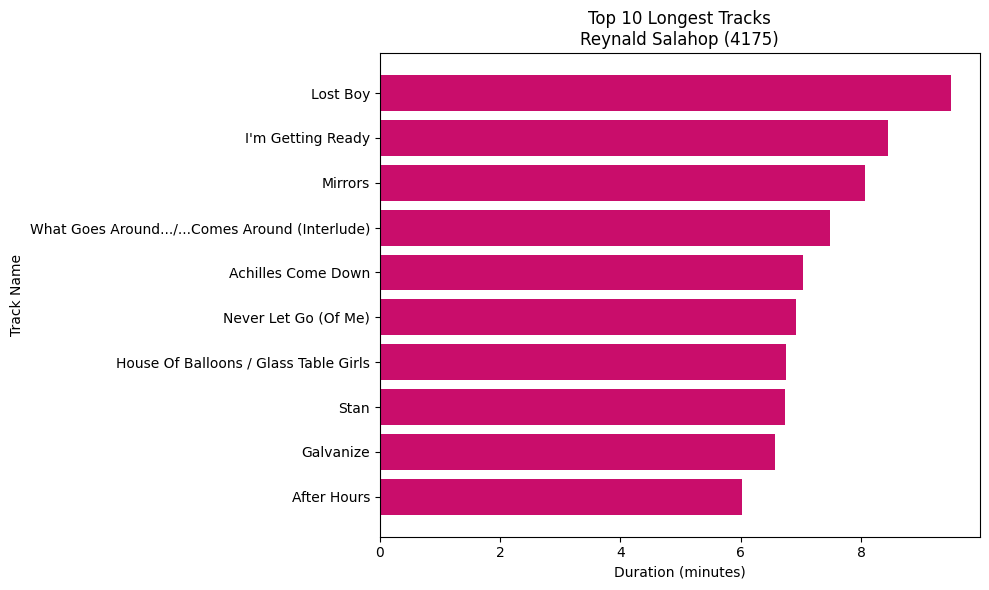

                                          track_name                 artist  \
710                                         Lost Boy                  Jaden   
610                                I'm Getting Ready    Tasha Cobbs Leonard   
64                                           Mirrors      Justin Timberlake   
63   What Goes Around.../...Comes Around (Interlude)      Justin Timberlake   
622                               Achilles Come Down         Gang of Youths   
689                             Never Let Go (Of Me)                 Baltra   
682            House Of Balloons / Glass Table Girls             The Weeknd   
549                                             Stan                 Eminem   
671                                        Galvanize  The Chemical Brothers   
37                                       After Hours             The Weeknd   

     duration_min  
710      9.497883  
610      8.436667  
64       8.069100  
63       7.476217  
622      7.035767  
689      6

In [1]:
# Exercise 1
import pandas as pd
import matplotlib.pyplot as plt

# --- STANDALONE SETUP ---
student_name = "Reynald Salahop"
student_id = "4175"
# Personalized color generation (re-defined here to avoid NameError)
id_num = int(student_id[-3:])
color_bar = f"#{ (id_num * 7) % 256:02x}{(id_num * 3) % 256:02x}{(id_num * 5) % 256:02x}"

# Load Dataset (Update path as needed)
dataset_path = r"C:\Users\CLienT\Documents\COMPROG LAB\spotify_top_1000_tracks.csv"
df = pd.read_csv(dataset_path)

# --- CALCULATIONS ---
# 1. Sort by duration and select top 10 [cite: 632, 633]
longest_tracks = df.nlargest(10, 'duration_min')[['track_name', 'artist', 'duration_min']]

# --- VISUALIZATION ---
plt.figure(figsize=(10, 6))
plt.barh(longest_tracks['track_name'], longest_tracks['duration_min'], color=color_bar)
plt.xlabel('Duration (minutes)')
plt.ylabel('Track Name')
plt.title(f"Top 10 Longest Tracks\n{student_name} ({student_id})")
plt.gca().invert_yaxis()  # Invert to show longest at the top
plt.tight_layout()
plt.show()

# Output the table as requested [cite: 634]
print(longest_tracks)


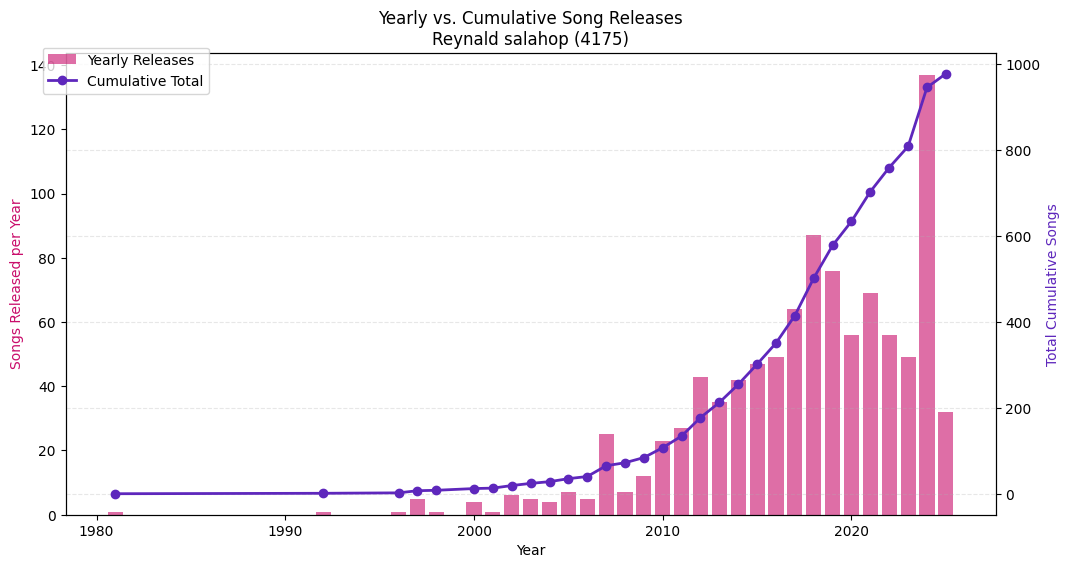

In [3]:
# Exercise 2
import pandas as pd
import matplotlib.pyplot as plt

# --- STANDALONE SETUP ---
student_name = "Reynald salahop"
student_id = "4175"
id_num = int(student_id[-3:])
color_bar = f"#{ (id_num * 7) % 256:02x}{(id_num * 3) % 256:02x}{(id_num * 5) % 256:02x}"
color_line = f"#{ (id_num * 2) % 256:02x}{(id_num * 9) % 256:02x}{(id_num * 4) % 256:02x}"

# Load and Preprocess Year
df = pd.read_csv(r"C:\Users\CLienT\Documents\COMPROG LAB\spotify_top_1000_tracks.csv")
df['year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year
df = df.dropna(subset=['year'])

# --- CALCULATIONS ---
# 1. Group by year and count releases [cite: 637]
yearly_counts = df.groupby('year').size().sort_index()
# 2. Calculate cumulative growth [cite: 638]
cumulative_growth = yearly_counts.cumsum()

# --- VISUALIZATION ---
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary Axis: Yearly Releases (Bar) [cite: 638]
ax1.bar(yearly_counts.index, yearly_counts.values, color=color_bar, alpha=0.6, label='Yearly Releases')
ax1.set_ylabel('Songs Released per Year', color=color_bar)
ax1.set_xlabel('Year')

# Secondary Axis: Cumulative Total (Line) [cite: 638]
ax2 = ax1.twinx()
ax2.plot(cumulative_growth.index, cumulative_growth.values, color=color_line, marker='o', linewidth=2, label='Cumulative Total')
ax2.set_ylabel('Total Cumulative Songs', color=color_line)

plt.title(f"Yearly vs. Cumulative Song Releases\n{student_name} ({student_id})")
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

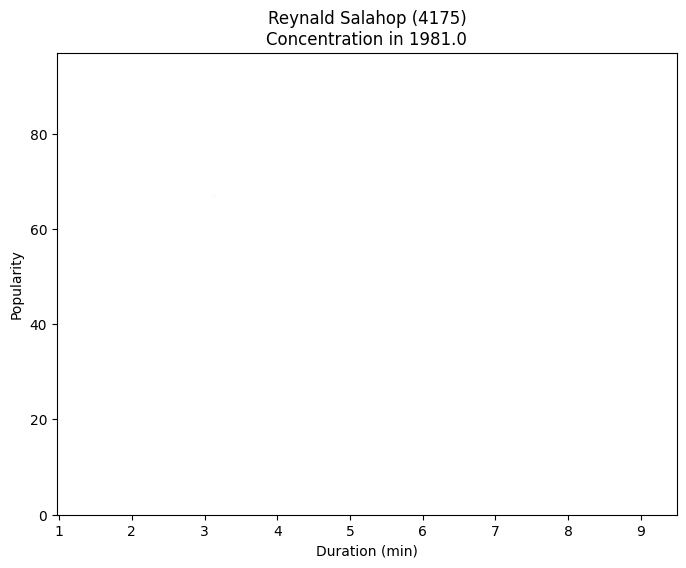

In [6]:
# Exercise 3
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# 1. Setup Student Parameters
student_name = "Reynald Salahop"
student_id = "4175"
cmap_color = "Purples"  

# 2. Prepare Data
# Sorting by year is crucial for a smooth animation progression
years = sorted(df['year'].unique())

fig, ax = plt.subplots(figsize=(8, 6))

def update(year):
    ax.clear() # Clear the previous year's hexbins
    
    # Filter data for the current year in the animation frame
    data_year = df[df['year'] == year]
    
    # 3. Calculations: Create the Hexbin Density Map
    hb = ax.hexbin(
        data_year['duration_min'], 
        data_year['popularity'], 
        gridsize=20, 
        cmap=cmap_color,
        mincnt=1 # Only show bins with at least one song
    )

    # 4. Customization & Student Personalization
    ax.set_title(f"{student_name} ({student_id})\nConcentration in {year}")
    ax.set_xlabel("Duration (min)")
    ax.set_ylabel("Popularity")
    ax.set_xlim(df['duration_min'].min(), df['duration_min'].max())
    ax.set_ylim(df['popularity'].min(), df['popularity'].max())
    
    return hb,

# 5. Create the Animation
# frames=years tells the function to loop through each unique year
ani = FuncAnimation(fig, update, frames=years, interval=500, repeat=True)

HTML(ani.to_jshtml())